# A Coffee Shop Daily Profit Forecasting Model

In the **Monte Carlo Method Article** we saw, **what the Monte Carlo Method is**, **how it works**, and **what it needs to be working**!

So, that was the required knowledge we should have gathered, in order to create the algorithm of this **forecasting model**.And now, when we have those skills, we can easily start the development.

##### But first, let's actually, understand and specify the aim of the **forecasting model** we are going to develop:

Take for example a local coffee shop.The owner, tries to **predict** the daily income of it's coffee, but like many others, he relies on **deterministic, statical** assumptions, which creates a **false** sense of security, masking the very real risks of sudden supplier price hikes, **unexpected** bad weather, or seasonal dips in foot traffic.

The fundamental flaw in relying on a single-point estimations for future business outcomes, is that it completely ignores the **inherent volatility** of the real world.When a coffee shop owner assumes they will serve exactly 150 customers every day, or that the wholesale cost of coffee beans will remain perfectly static, they are building a financial model on a **fragile foundation**. 

As it is **expected** the methods, used by the owner are false every single time, just because, even that he tries to predict some edge case scenarios, there will always be something unexpected that is simply beyond his powers to foresee and predict.

However, the owner has finaly decided that he wants to have a better clarity on his financial incomes.In order to so, the owner needs a solid forecastig model, which predicts his coffee shop daily profit.

#### And here we come to the aim of the project:
> To overcome the **limitations** of the **traditional forecasting**, this project implements a **Monte Carlo Risk Simulation**. Rather than relying on **rigid, single-point assumptions**, this **computational framework** embraces real-world uncertainty by assigning **statistical probability distributions** to volatile variables, such as daily customer foot traffic and fluctuating wholesale costs.

By running **thousands** of simulated business days, the engine generates a **comprehensive** spectrum of possible financial outcomes and calculates the exact **likelihood** of each occurring.

For the coffee shop owner, this means replacing a fragile 'best guess' with a robust, data-driven forecast. It provides immediate clarity on critical business questions, highlighting not just the **expected average profit**, but the **exact probability** of operating at a **loss** on any given day or the **likelihood** of achieving specific revenue targets.

### With this clarification, we are totally ready to start the development of the algorithm and all of it's components!

Ok now let's first start by defining the ***Base Mathematical Model***, on which the daily profit is going to be calculated.

The **daily profit** is defined as:
$$
    Profit = (N \times (P - C_v)) - C_f
$$

Where:
- $N$: Number of customers
- $P$: Price per order
- $C_v$: Variable cost per order
- $C_f$: Fixed daily cost(overhead)

Ok, we have defined the base model, and identified it's components, but which of these components are actually going to be **predicted**?

As *Chat gpt*[1] says: \
In real-world systems, uncertainty arises from:
- Customer arrivals (demand uncertainty)
- Supply cost variability
- Market conditions

And this is logical, because we can never be sure the amount of customers, which are going to come and buy coffee. \
We also can't be sure about the variable cost per order, such us beans, milk, cups - these are all defined as variables with unsetteled prices and inflationary changes!

Now we can surely say that the **Random Varibles**, in this case are going to be:
- $N$: The number of customers
    - Daily variability (weekday vs weekend)
    - Primary driver of revenue
    - Major contributor to the variance in profit

- $C_v$: The variable cost per order
    - Supply chain volatility (coffee beans, milk)
    - Market price changes (commodities)
    - Operational inefficiencies
    - Supplier variability

However, we should also define the **Deterministic (Fixed) Variables**:
- $P$: The price per Order
    - Set by the business
    - Changes infrequently relative to daily operations

- $C_f$: The daily overhead
    - Includes rent, salaries, utilities
    - Typically constant on a daily basis
    - Known in advance with high certainty

Okay, now that we've clarified each of the model components and understood their roles in the algorithm,let's also put a little attention on the thing that is going to drive the algorithm and it's simulations:
#### - The Probability distributions

We drive the simulations, by sampling many times from the distributions of the random variables.

Each simulation run represents:
> A possible prediction of a business day.

Thus, the entire variability of profit emerges from:
- Demand randomness (N)
- Cost randomness ($C_v$)

### Which distributions are going to be used and why?
By making a comprehensive research I have stopped at the [*Normal*](https://en.wikipedia.org/wiki/Normal_distribution) as a distribution for the **customers** and the [*Triangular*](https://en.wikipedia.org/wiki/Triangular_distribution) for the variable costs.

#### So, why them?
### 1.Normal Distribution for Customer Count ($N$):
$$
    N \sim \mathcal{N}(\mu_N, \sigma_{N}^{2})
$$
As the **Central Limit Theorem** states:
> The sum of many independent random influences converges to a Normal distribution.

If we assume that customer arrivals are influenced by many small, independent factors:
- Individual decisions
- Weather
- habits
- local activity

Then:
$$
    N = X_1 + X_2 + X_3,...X_i
$$

Where each $X_i$ is a small contributing factor.

So, we can say that $N$ is approximately Normal.

### 2.Triangular Distribution for Variable Cost ($C_v$):
$$
    C_v \sim \mathcal{T}(a, m, b)
$$

Where:
- a: minimum
- m: most likely (mode)
- b: maximum

For a coffee shop:
- Minimum cost = stable supply scenario
- Maximum cost = shortage/spike
- Mode = typical operating condition

Why not **Normal** for the variable costs?
- Costs are bounded (cannot be negative)
- Often asymmetric (price spikes, drops)
- Normal distribution violates these constraints

Well, I think we've gone through all the important details that we had to take into account and specified everything that needed to be specified, and it's time to move on to the essential part, namely the development of the algorithm.

To start with, we are going to implement, a general version of the algorithm.By general, I mean that it will be used for the calculation of the main, but still very important, statistics such as, average profit, probability of loss, probability of achiving specific profit prices etc.

Let's make a quick structure of the algorithm and list down all of it's componenets:
- Random Variable Generators:
    - Responsible for sampling $N$ and $C_v$

- Profit Evaluation:
    - Implements: $ (N \times (P - C_v)) - C_f $

- Monte Carlo Simulations Engine:
    - Combines everything
    - Drives the simulations
    - Returns the calculated profits

- Input Parameter Module
    - Distribution parameters
    - Simulation size
    - Variable (fixed) Constants

- Extracting the results:
    - Using the input data, which drives the Monte Carlo simulations and gets the calculated profits
    - Returning statical data


Now the implementation:

In [9]:
import numpy as np
import matplotlib.pyplot as plt

First let's craete the function that will sample the customets from the **Normal distribution**:

In [2]:
def sample_customers_normal(mean, sd, size):
    """
    1) Samples the customers from a Normal distribution, by ensuring only whole numbers and no negative values!
    2) Rounding the samples to integers.
    3) Ensuring no-negative numbers.
    4) Returns the generated, processed samples.
    """
    samples = np.random.normal(mean, sd, size)
    
    # Here we rounds the numbers to the nearest whole number
    samples = np.rint(samples).astype(int)
    
    # Ensuring no negative values 
    samples = np.maximum(samples, 0)
    
    return samples

Now let's create the function, which will sample the varible costs from the **Triangular distribution**:

In [3]:
def sample_costs_triangular(min, mode, max, size):
    """
    1) Samples the variables costs from a triangular distribution.
    2) Returning the samples.
    """
    
    return np.random.triangular(min, mode, max, size)

Now, let's the define the function which will evaluate the base model with the sampled data:

In [4]:
def simulate_profit(customers, price, cost_per_order, fixed_cost):
    """
    1) Calculates the profit, by the formula:
        customers * (price - cost_per_order) - fixed_cost.
    2) Returns the profit.
    """
    
    # First we multiply the amount of customers with the prive per order
    # Second, we are calculating the variable costs per order for all of the customers
    # Then, extracting the costs from the revenue
    revenue = customers * price
    total_var_cost = customers * cost_per_order
    profit = revenue - (total_var_cost + fixed_cost)
    
    return profit

Now that we have defined the sampling functions, let's use them for running of the simulations and processing the result:

In [5]:
def run_monte_carlo_simulation(simulations_size, 
                               mean_customers, sd_customers, 
                               cost_min, cost_mode, cost_max, 
                               price, fixed_cost):
    """
    1) Performs a Monte Carlo Simulation
    2) Generates Random Samples
    3) Calculating the base model using the samples
    4) Retuns the caclulated result
    """
    
    N_samples = sample_customers_normal(mean_customers, sd_customers, simulations_size)
    Cv_samples = sample_costs_triangular(cost_min, cost_mode, cost_max, simulations_size)
    
    # Calculating the profit, by appling the generated samples on the base model
    profits = simulate_profit(N_samples, price, Cv_samples, fixed_cost)
    
    return profits

Now let's define the input data and use it to estimate the profits:

In [ ]:
# Example input data:
mean_customers = 100     # the average amount of customers per day
sd_customers = 20        # the standard deviation
price_per_order = 5.0    # price per order (fixed)
fixed_cost_daily = 200   # fixed daily overhead
cost_min = 0.5           # min variable cost
cost_mode = 0.6          # most likely variable cost
cost_max = 0.8           # max variable cost

# Performing the simulations
simulations_size = 100000
profits = run_monte_carlo_simulation(simulations_size, 
                                     mean_customers, sd_customers,
                                     cost_min, cost_mode, cost_max,
                                     price_per_order, fixed_cost_daily)

# Analyzing the profits
average_profit = np.mean(profits) # The average mean (the expected value)
prob_loss = np.mean(profits < 0)  # The probabiity that the profit will be negative
prob_high = np.mean(profits >= 500)  # The probability that the profit will exceed 500

# Calculating some Value-at-Risk (VaR)
# The `percentile` function measures the value at which a certain percentage of the data falls.
var_5 = np.percentile(profits, 5) # The 5 percent of the profits will have a worse value than this
var_1 = np.percentile(profits, 1) # Worst case scenarios - scenarions with probability one percent!
var_50 = np.percentile(profits, 50) # The median

# Most likely profit is approcimatelly equal to:
print(f"Average mean: {average_profit:.2f}")

# We multiply these by 100, to see approximately the percentages, but they are actually very less smaller than the shown values!
print(f"Probability of loss: {prob_loss*100:.1f}%")
print(f"Probability to get profit higher than 500: {prob_high*100:.1f}%")

# Edge case scenarios:
print(f"Value at risk 5%: {var_5:.2f}")
print(f"Value at risk 1%: {var_1:.2f}")
print(f"Value at risk 50%: {var_50:.2f}")


Average mean: 236.66
Probability of loss: 0.3%
Probability to get profit higher than 500: 0.1%
Value at risk 5%: 92.01
Value at risk 1%: 32.29
Value at risk 50%: 236.65


What we can see from the results?
- We got an average mean **236.16** as the expected value for our daily profits, based on the data we gave.
- Next we can see that a **probability of loss** is expected to equal **0.3** percentages, which means that there is **0.3**% chance to produce a negative profit, which is actually a very low chance!
- There is a **0.1% chance to exceed **500**
- In **5%** of the cases it is expected that the profit will be less then or equal to **91.93**, or also we can say that the results which fall under the value of **91.93** have probability of 5% chance of happening.
- In **1%** of the cases it is expected that the profit will be less then or equal to **31.76**
- We can also see that the value under which falls the **50%** of data is the **median**, or the **expected value**: **236**

#### Now lets visualize the results and see what we can understand from them:

To start with lets see the distribution of the profits and how are they concentrated around the mean value!

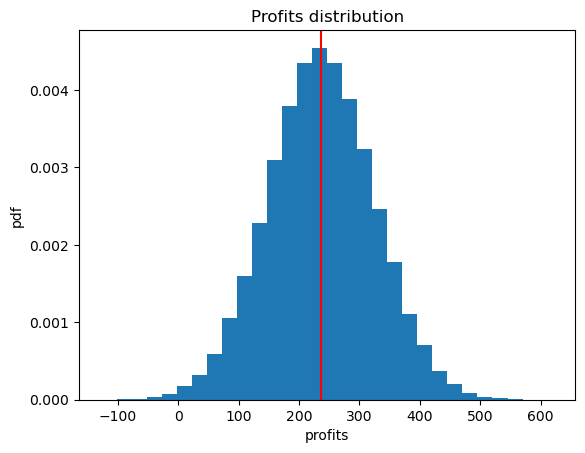

In [ ]:
plt.hist(profits, bins=30, density=True)

# The expected mean value
plt.axvline(average_profit, c='r')

plt.xlabel('profits')
plt.ylabel('pdf')
plt.title('Profits distribution')

plt.show()

We can see a continuous probability density of profit outcomes
- It is Bell-shaped (approximately normal)
- It is stable and centered around mean: 236
- Most outcomes fall roughly between: 100 and 350
- Customer demand is symmetric (Normal)

Slight skewness may exist due to triangular costs
Left tail (loss region) is very thin - low risk
- Costs are bounded → prevents extreme losses


Now lets visualize some **Risk Zones** metrics:

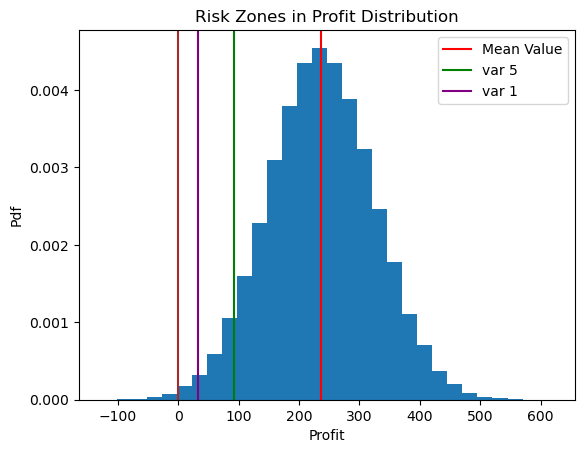

In [23]:
# Compute statistics
mean_value = np.mean(profits)
var_5 = np.percentile(profits, 5)
var_1 = np.percentile(profits, 1)

plt.figure()

# Histogram of profits
plt.hist(profits, bins=30, density=True)

# The vertical lines marking important thresholds
plt.axvline(mean_value, c='r', label='Mean Value')   # Expected value
plt.axvline(var_5, c='g', label='var 5')      # 5% worst-case threshold
plt.axvline(var_1, c='purple', label='var 1') # 1% extreme risk threshold
plt.axvline(0, c='brown')      # Break-even line

plt.title("Risk Zones in Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Pdf")

plt.legend()
plt.show()

What is plotted:
- Mean (236): Center of distribution
- VaR 5% (92): Worst 5% of days still profitable
- VaR 1% (32): Extreme worst-case still positive


We can see that the entire risk structure is shifted into **positive territory**, which means that the business is highly resilient.
- No extreme shocks modeled
- Stable demand and cost structure
- The probability of loss is extremely low (0.3%)

Now lets see how the **average profit and the probability of loss** varies over time as the **amount of customers changes**:

To do so I will define a function, which accepts another function as the simulation engine and all other required parameters for the simulations.

In [27]:
def plot_avg_profit_and_risk_over_time(simulation_function, params, customer_range):
    """
    Analyzes how profit and risk change as average customer count changes.

    Parameters:
    run_simulation : function
        The Monte Carlo function
    base_params : dict
        Dictionary with all simulation required parameters
    customer_range : array
        Range of mean customer values to test
    """

    avg_profits = []
    loss_probs = []

    for m in customer_range:
        profits = simulation_function(
            params["simulations"],
            m,
            params["sd"],
            params["cmin"],
            params["cmode"],
            params["cmax"],
            params["price"],
            params["fixed"]
        )

        avg_profits.append(np.mean(profits))
        loss_probs.append(np.mean(profits < 0))

    # Plot average profit
    plt.figure()
    
    plt.plot(customer_range, avg_profits)
    
    plt.title("Average Profit vs Mean Customers")
    plt.xlabel("Mean Customers")
    plt.ylabel("Average Profit")
    
    plt.show()

    # Plot probability of loss
    plt.figure()
    
    plt.plot(customer_range, loss_probs)
    
    plt.title("Probability of Loss vs Mean Customers")
    plt.xlabel("Mean Customers")
    plt.ylabel("Probability of Loss")
    
    plt.show()

Now lets test it:

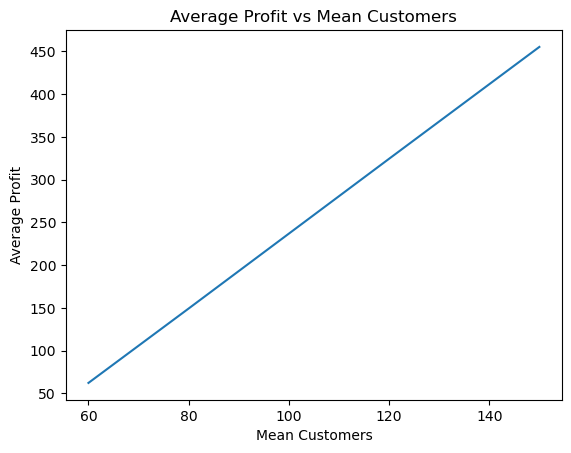

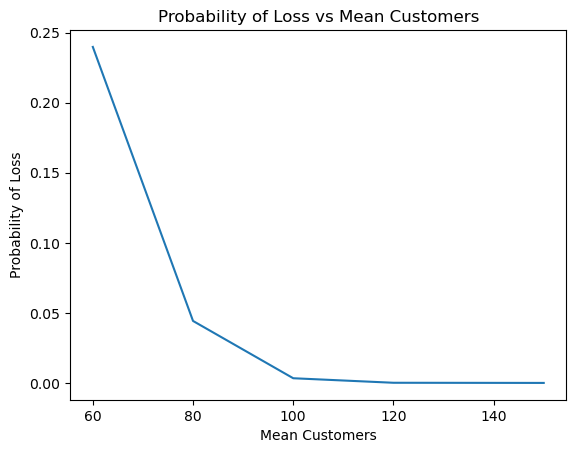

In [28]:
# Example input data:
mean_customers = 100     # the average amount of customers per day
sd_customers = 20        # the standard deviation
price_per_order = 5.0    # price per order (fixed)
fixed_cost_daily = 200   # fixed daily overhead
cost_min = 0.5           # min variable cost
cost_mode = 0.6          # most likely variable cost
cost_max = 0.8           # max variable cost

customers_range = [60, 80, 100, 120, 150]
plot_avg_profit_and_risk_over_time(simulation_function=run_monte_carlo_simulation, params={
    'simulations': simulations_size,
    'sd': sd_customers,
    'cmin': cost_min,
    'cmode': cost_mode,
    'cmax': cost_max,
    'price': price_per_order,
    'fixed': fixed_cost_daily
}, customer_range=customers_range)

From the first plot we can see how as the number of mean customers increases, the average mean becomes higher and higher, and this is logical because more customers leads to more orders which leads to bigger profit.

Average Profit vs Customers:
- Perfect linear relationship
- Profit scales linearly with $N$


From the second plot we can see that as the number of customer increases, the prob of loss decreases.
Probability of Loss vs Customers
- Around 100 customers, there is near-zero loss probability
- Below 80 - risk increases sharply

Now lets see something very interesting.Which control variables (customers, prices, costs etc) have the biggest impact on a specific output result.

To do so I will use the so called **Tornado Chart** which is specifically designed to show that.


In [ ]:
def plot_tornado(simulation_function, base_params):
    """
    Measures sensitivity of profit to changes in key variables.

    - Slightly change each variable (+10%)
    - Measure impact on mean profit
    """

    # Calculating the base profit, before the changes
    base_profit = np.mean(simulation_function(**base_params))

    # The array where each of the control variable impacts will be collected
    impacts = {}

    # Modifing each parameter individually
    # For this example, I will modify only the Customers, the price per order and the max cost per order
    scenarios = {
        "Customers": {**base_params, "mean_customers": base_params["mean_customers"] * 1.1},
        "Price per order": {**base_params, "price": base_params["price"] * 1.1},
        "Max cost per order": {**base_params, "cost_max": base_params["cost_max"] * 1.2},
    }

    # Calculating the new results after the changes
    for key, params in scenarios.items():
        new_profit = np.mean(simulation_function(**params))
        impacts[key] = new_profit - base_profit

    # Plotting a horizontal bar chart
    plt.figure()
    
    plt.barh(list(impacts.keys()), list(impacts.values()))

    plt.title("Tornado Chart (Variable Impact on Profit)")
    plt.xlabel("Change in Mean Profit")

    plt.show()

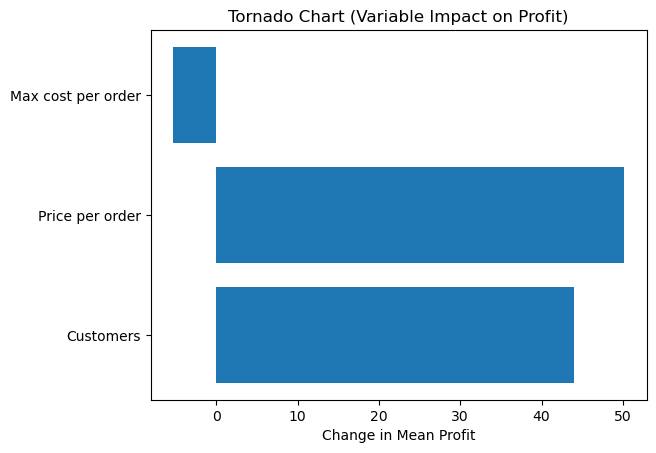

In [42]:
plot_tornado(simulation_function=run_monte_carlo_simulation, base_params={
    'simulations_size': simulations_size,
    'mean_customers': mean_customers,
    'sd_customers': sd_customers,
    'cost_min': cost_min,
    'cost_mode': cost_mode,
    'cost_max': cost_max,
    'price': price_per_order,
    'fixed_cost': fixed_cost_daily
})

What it shows: \
Impact of increasing each variable with approximate of 10%

We can see how the biggest impact, over the mean value, has the control variable of **price per order**.

Price:
- largest impact
- direct multiplier - strongest leverage

Customers:
- middle impact
- strong but dependent on variability

Cost max:
- minimal impact
- smaller relative variation - smaller effect

One thing we may want to see, is how the profits accumulates over time.Are there any drawdowns?

In [49]:
def plot_time_simulation(simulation_function, params, days=100):
    """
    Simulates profit over multiple days and visualizes accumulation.
    
    Parameteres:
    simulation_function : function
        The Monte Carlo function
    params:
        The required input for the Monte Carlo simulation
    days : int
        Number of simulated days
    """

    # Simulate daily profits
    profits = simulation_function(
        days,
        params["mean_customers"],
        params["sd"],
        params["cmin"],
        params["cmode"],
        params["cmax"],
        params["price"],
        params["fixed"]
    )

    # Compute cumulative profit
    cumulative_profit = np.cumsum(profits)

    plt.figure()

    plt.plot(cumulative_profit)

    plt.title("Cumulative Profit Over Time")
    plt.xlabel("Days")
    plt.ylabel("Cumulative Profit")

    plt.show()

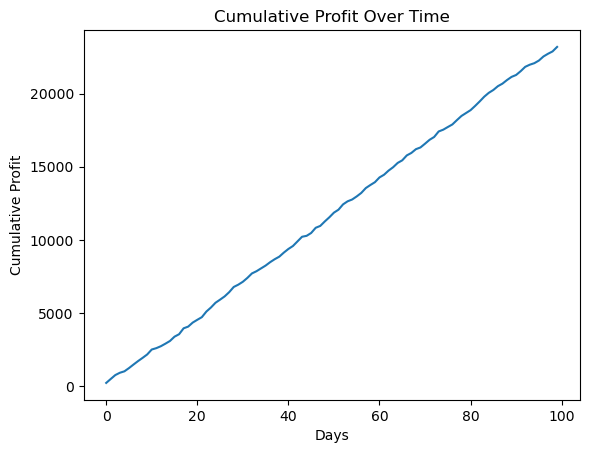

In [51]:
plot_time_simulation(simulation_function=run_monte_carlo_simulation, params={
    'simulations': simulations_size,
    'mean_customers': mean_customers,
    'sd': sd_customers,
    'cmin': cost_min,
    'cmode': cost_mode,
    'cmax': cost_max,
    'price': price_per_order,
    'fixed': fixed_cost_daily
}, days=100)

What we can see:
Profit accumulation over 100 days

- Smooth upward trend
- No major drawdowns
- Stability:
    - Daily profits consistently positive
- Growth:
    - Business generates steady income

This resembles a random walk with positive drift:
$$
    S_t = \sum^{t}_{i=1}\Pi_i
$$

What I mean with this is that: 
> **Even that it moves in an unpredictable, wandering manner, it has an overall upward trend over time.**

#### Ok, now as one last thing I want to show are the **confidence intervals**:
We already explained them into the Monte Carlo article, but know lets see how they apply in this specific case:

In [64]:
def plot_confidence_intervals(profits, z):
    """
    Estimates and visualizes the confidence interval of the mean profit.

    Parameters:
    profits : numpy.ndarray
        The distribution of the profits.
    z : float
        The z-statistic (or z-score/critical value) in a confidence interval represents the 
        number of standard deviations a value is from the mean in a standard normal distribution.
        It is multiplied by the standard error.
    """
    
    mean_profit = np.mean(profits)

    # Standard error of the mean
    std_error = np.std(profits) / np.sqrt(len(profits))

    # 95% confidence interval
    ci_low = mean_profit - (z * std_error)
    ci_high = mean_profit + (z * std_error)

    plt.figure()

    plt.hist(profits, bins=100, density=True)

    plt.xlim(220, 240)

    # Mark mean and confidence bounds
    plt.axvline(mean_profit, c='red')
    plt.axvline(ci_low, c='green')
    plt.axvline(ci_high, c='brown')

    plt.title("Confidence Interval for Mean Profit")
    plt.xlabel("Profit")
    plt.ylabel("Frequency")

    plt.show()

    print(f"95% Confidence Interval: [{ci_low:.2f}, {ci_high:.2f}]")

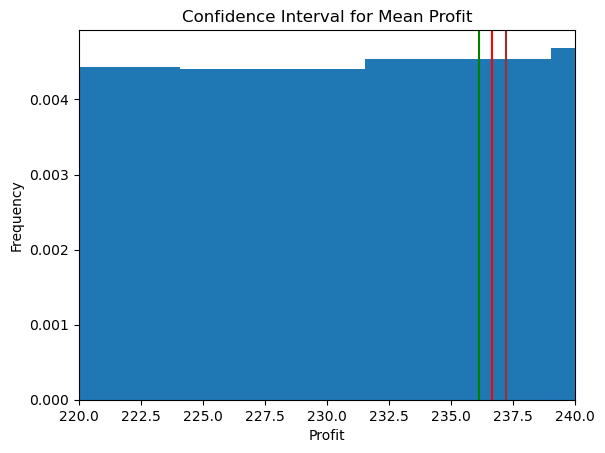

95% Confidence Interval: [236.12, 237.21]


In [66]:
z = 1.96
plot_confidence_intervals(profits, z)

What this confidence intervals tells us, is the percent of confidence(currently 95%) that the expected mean will lie in the range shown above.

We can see from the plot how small the interval is and how confident we should be, that the mean value will be lieing in that interval.We can be almost sure that with this data as an input, the result will be always in that interval.

- Extremely narrow interval
    - high precision
- Due to:
    - Large simulation size (100,000)
    - Stable system

This reflects:
$$
    \text{Std error} = \frac{\sigma}{\sqrt{N}}
$$

Large $N$ - very small uncertainty

#### What if we want even to be 99% sure?
Well we should only change the z-statistic.

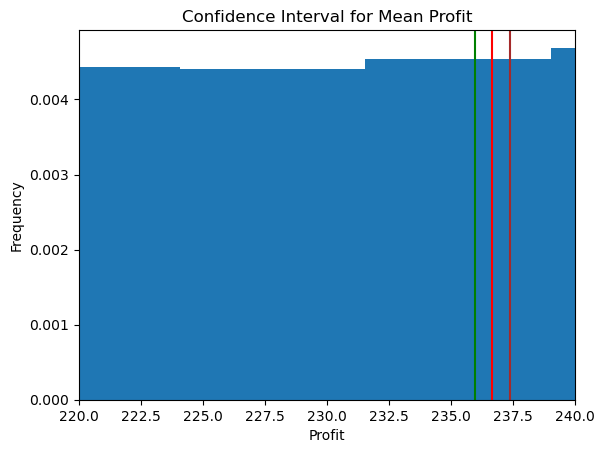

95% Confidence Interval: [235.95, 237.38]


In [67]:
z = 2.576
plot_confidence_intervals(profits, z)

#### If we want to be more sure in our assumptions, we must increase the confidence interval, which is logical!

### Ok, I think that we made enough meaningful and useful experiments and analysed the most important things from the given results.